# Random Forest Classification (From Scratch)

A Random Forest built from first principles (no `sklearn.ensemble.RandomForestClassifier`, no `sklearn` tree modules) to predict Titanic passenger survival. `numpy`/`pandas` are used only for data handling. Every piece of the algorithm itself (Gini impurity, information gain, best-split search, bootstrap sampling, random feature selection, majority-vote prediction) is implemented directly in this notebook.

**Data note**: the brief points at the Kaggle Titanic competition, whose `test.csv` deliberately withholds the `Survived` labels (they're used for competition scoring, not available to us). Since Part 4 of the brief asks us to make our own 80/20 train/validation split anyway, this notebook instead loads the classic 891-row labeled Titanic set (same columns, same data, a well-known open mirror of Kaggle's `train.csv`) and does the 80/20 split itself, which is both truer to the assignment's own instructions and avoids needing a Kaggle API key.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid')

## Part 1: Data exploration & understanding

In [2]:
TITANIC_URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(TITANIC_URL)

print('shape:', df.shape)
print(df.dtypes)
df.head()

shape: (891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


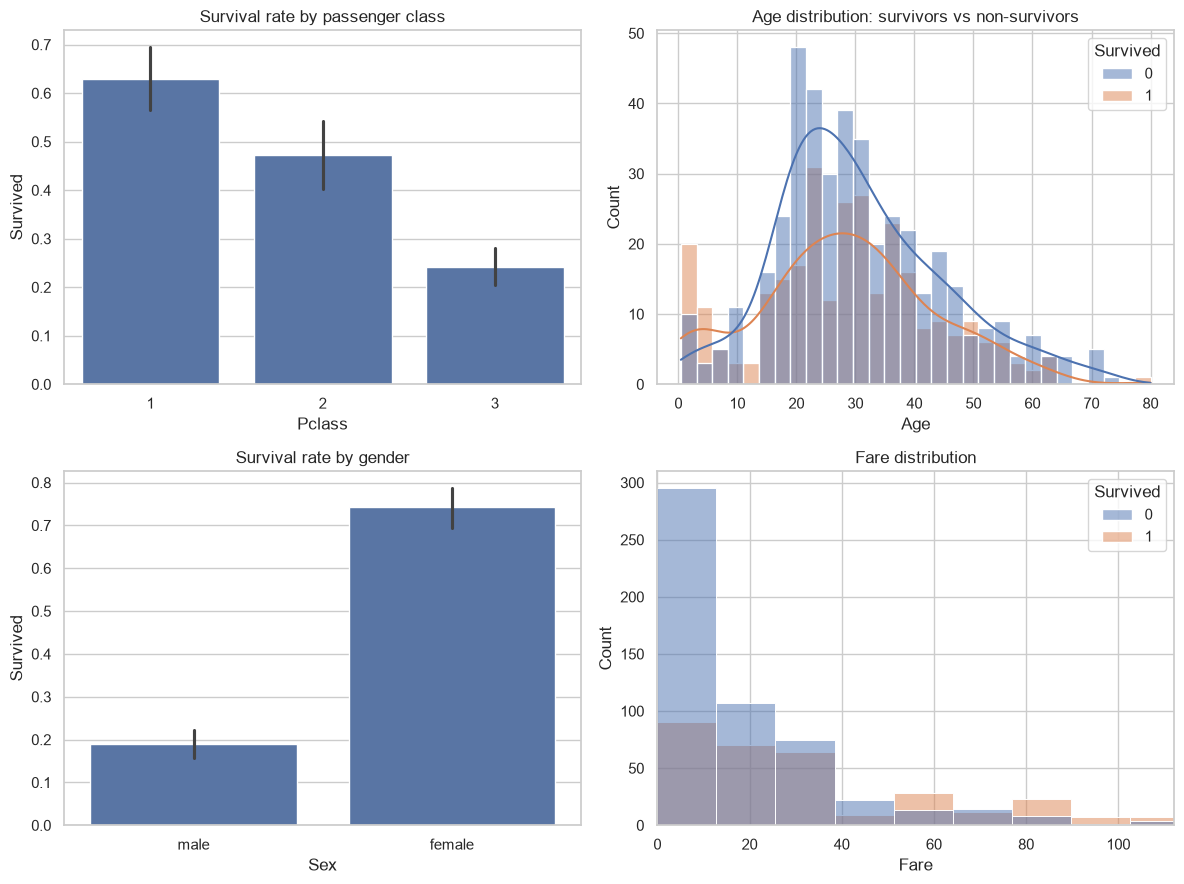

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.barplot(data=df, x='Pclass', y='Survived', ax=axes[0, 0])
axes[0, 0].set_title('Survival rate by passenger class')

sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Age distribution: survivors vs non-survivors')

sns.barplot(data=df, x='Sex', y='Survived', ax=axes[1, 0])
axes[1, 0].set_title('Survival rate by gender')

sns.histplot(data=df, x='Fare', hue='Survived', bins=40, ax=axes[1, 1])
axes[1, 1].set_xlim(0, df['Fare'].quantile(0.95))
axes[1, 1].set_title('Fare distribution')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120)
plt.show()

Cabin       687
Age         177
Embarked      2
dtype: int64


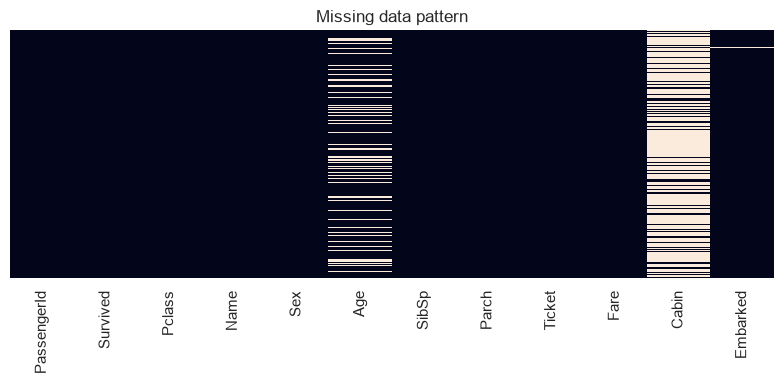

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing)

plt.figure(figsize=(8, 4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title('Missing data pattern')
plt.tight_layout()
plt.savefig('missing_data.png', dpi=120)
plt.show()

`Age` and `Embarked` are missing for a small number of rows and can be reasonably imputed. `Cabin` is missing for most of the dataset; better treated as a 'do we even know the cabin' signal (`HasCabin`) than imputed directly.

## Part 2: Preprocessing & feature engineering

In [6]:
data = df.copy()

# --- missing values ---
data['Title'] = data['Name'].str.extract(r',\s*([^.]*)\.')
age_by_title = data.groupby('Title')['Age'].transform('median')
data['Age'] = data['Age'].fillna(age_by_title)
data['Age'] = data['Age'].fillna(data['Age'].median())

data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

data['HasCabin'] = data['Cabin'].notna().astype(int)

# --- feature engineering ---
rare_titles = data['Title'].value_counts()[data['Title'].value_counts() < 10].index
data['Title'] = data['Title'].replace(rare_titles, 'Rare')

data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

data['AgeBin'] = pd.cut(data['Age'], bins=[0, 12, 18, 30, 45, 60, 100], labels=False)
data['FareBin'] = pd.qcut(data['Fare'], q=5, labels=False, duplicates='drop')

# --- encode categoricals ---
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
data['Title'] = data['Title'].astype('category').cat.codes
embarked_dummies = pd.get_dummies(data['Embarked'], prefix='Embarked', drop_first=True)
data = pd.concat([data, embarked_dummies], axis=1)

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,HasCabin,FamilySize,IsAlone,AgeBin,FareBin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,2,0,2,0,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,3,1,2,0,3,4,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,0,1,1,2,1,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,3,1,2,0,3,4,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,2,0,1,1,3,1,False,True


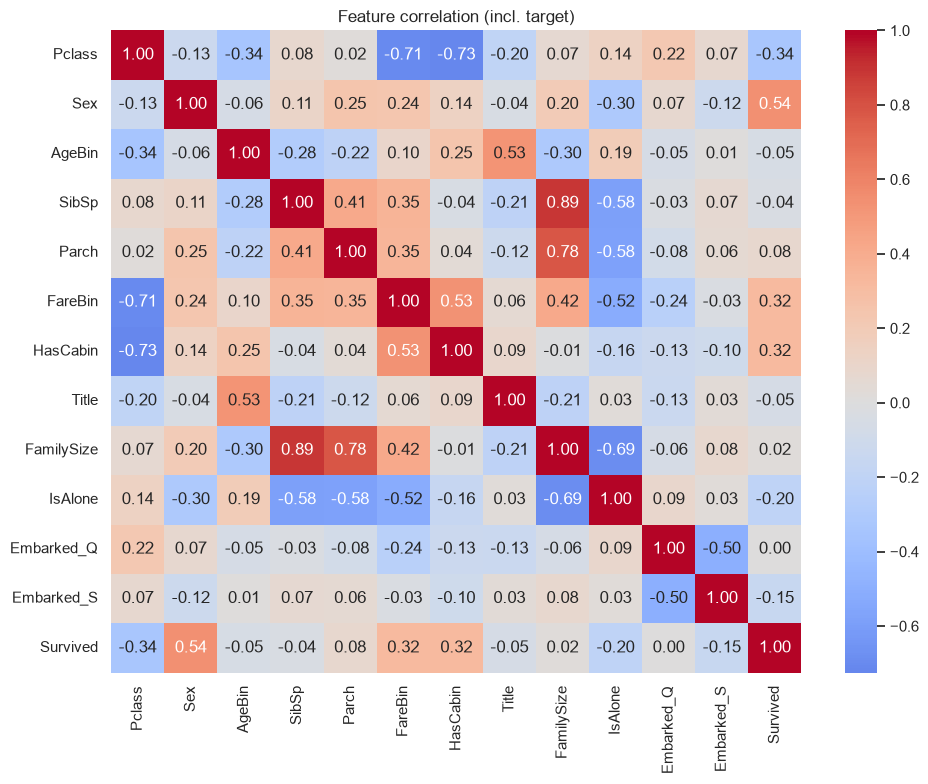

In [7]:
FEATURE_COLS = [
    'Pclass', 'Sex', 'AgeBin', 'SibSp', 'Parch', 'FareBin',
    'HasCabin', 'Title', 'FamilySize', 'IsAlone',
] + list(embarked_dummies.columns)
TARGET_COL = 'Survived'

model_df = data[FEATURE_COLS + [TARGET_COL]].astype(float)

plt.figure(figsize=(10, 8))
sns.heatmap(model_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature correlation (incl. target)')
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=120)
plt.show()

In [8]:
X = model_df[FEATURE_COLS].values
y = model_df[TARGET_COL].values.astype(int)

n_val = int(0.2 * len(X))
rng = np.random.RandomState(SEED)
perm = rng.permutation(len(X))
val_idx, train_idx = perm[:n_val], perm[n_val:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]

print('train:', X_train.shape, ' val:', X_val.shape)
print('train survival rate:', y_train.mean().round(3), ' val survival rate:', y_val.mean().round(3))

train: (713, 12)  val: (178, 12)
train survival rate: 0.377  val survival rate: 0.41


## Part 3: Random Forest, implemented from scratch

`DecisionTree` builds a single CART-style tree using Gini impurity to score splits. `RandomForest` wraps many of them, each trained on a bootstrap resample and restricted, at every split, to a random subset of features (`random_feature_selection`). These are the two sources of randomness that decorrelate the trees and are what make a *random* forest better than a plain bagged ensemble of identical trees.

In [9]:
class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2, criterion='gini', feature_selector=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        # optional callable(n_total_features) -> array of feature indices to consider at each split.
        # RandomForest passes its own random_feature_selection here; a plain DecisionTree leaves
        # this as None and considers every feature, same as a normal CART tree.
        self.feature_selector = feature_selector
        self.tree = None
        self.feature_importances_ = None
        self._classes = None

    def gini_impurity(self, y):
        if len(y) == 0:
            return 0.0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / counts.sum()
        return 1.0 - np.sum(probs ** 2)

    def _weighted_child_impurity(self, y_left, y_right):
        n = len(y_left) + len(y_right)
        if n == 0:
            return 0.0
        return (len(y_left) / n) * self.gini_impurity(y_left) + (len(y_right) / n) * self.gini_impurity(y_right)

    def information_gain(self, y, y_left, y_right):
        return self.gini_impurity(y) - self._weighted_child_impurity(y_left, y_right)

    def split_data(self, X, y, feature, threshold):
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        return X[left_mask], y[left_mask], X[right_mask], y[right_mask]

    def best_split(self, X, y, feature_indices):
        best_gain, best_feature, best_threshold = -1.0, None, None
        for feature in feature_indices:
            values = np.unique(X[:, feature])
            if len(values) < 2:
                continue
            thresholds = (values[:-1] + values[1:]) / 2.0
            for threshold in thresholds:
                _, y_left, _, y_right = self.split_data(X, y, feature, threshold)
                if len(y_left) == 0 or len(y_right) == 0:
                    continue
                gain = self.information_gain(y, y_left, y_right)
                if gain > best_gain:
                    best_gain, best_feature, best_threshold = gain, feature, threshold
        return best_feature, best_threshold, best_gain

    def _select_feature_indices(self, n_total_features):
        if self.feature_selector is None:
            return np.arange(n_total_features)
        return self.feature_selector(n_total_features)

    def _majority_class(self, y):
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def _class_proba(self, y):
        counts = np.array([(y == c).sum() for c in self._classes], dtype=float)
        return counts / counts.sum()

    def _build_tree(self, X, y, depth):
        n_samples, n_total_features = X.shape
        if len(np.unique(y)) == 1 or n_samples < self.min_samples_split or (self.max_depth is not None and depth >= self.max_depth):
            return {'leaf': True, 'prediction': self._majority_class(y), 'proba': self._class_proba(y)}

        feature_indices = self._select_feature_indices(n_total_features)
        feature, threshold, gain = self.best_split(X, y, feature_indices)
        if feature is None or gain <= 0:
            return {'leaf': True, 'prediction': self._majority_class(y), 'proba': self._class_proba(y)}

        self.feature_importances_[feature] += gain * n_samples
        X_left, y_left, X_right, y_right = self.split_data(X, y, feature, threshold)
        return {
            'leaf': False,
            'feature': feature,
            'threshold': threshold,
            'left': self._build_tree(X_left, y_left, depth + 1),
            'right': self._build_tree(X_right, y_right, depth + 1),
        }

    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y)
        self._classes = np.unique(y)
        self.feature_importances_ = np.zeros(X.shape[1])
        self.tree = self._build_tree(X, y, depth=0)
        total = self.feature_importances_.sum()
        if total > 0:
            self.feature_importances_ /= total
        return self

    def predict_sample(self, x, node=None):
        node = self.tree if node is None else node
        if node['leaf']:
            return node['prediction']
        branch = node['left'] if x[node['feature']] <= node['threshold'] else node['right']
        return self.predict_sample(x, branch)

    def predict(self, X):
        return np.array([self.predict_sample(x) for x in np.asarray(X)])

In [10]:
class RandomForest:
    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2, max_features='sqrt', random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []
        self.feature_importances_ = None

    def bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        indices = self._rng.randint(0, n_samples, size=n_samples)
        return X[indices], y[indices]

    def _features_per_split(self, n_total_features):
        if self.max_features == 'sqrt':
            return max(1, int(np.sqrt(n_total_features)))
        if self.max_features == 'log2':
            return max(1, int(np.log2(n_total_features)))
        if isinstance(self.max_features, int):
            return min(self.max_features, n_total_features)
        return n_total_features

    def random_feature_selection(self, n_total_features):
        k = self._features_per_split(n_total_features)
        return self._rng.choice(n_total_features, size=k, replace=False)

    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y)
        self._rng = np.random.RandomState(self.random_state)
        n_total_features = X.shape[1]
        self.trees = []
        importances = np.zeros(n_total_features)
        for _ in range(self.n_estimators):
            X_sample, y_sample = self.bootstrap_sample(X, y)
            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                feature_selector=self.random_feature_selection,
            )
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
            importances += tree.feature_importances_
        self.feature_importances_ = importances / self.n_estimators
        return self

    def predict(self, X):
        X = np.asarray(X)
        tree_preds = np.array([tree.predict(X) for tree in self.trees])  # (n_trees, n_samples)
        predictions = np.empty(X.shape[0], dtype=tree_preds.dtype)
        for i in range(X.shape[0]):
            values, counts = np.unique(tree_preds[:, i], return_counts=True)
            predictions[i] = values[np.argmax(counts)]
        return predictions

    def predict_proba(self, X):
        X = np.asarray(X)
        classes = self.trees[0]._classes
        probs = np.zeros((X.shape[0], len(classes)))
        for tree in self.trees:
            for i, x in enumerate(X):
                node = tree.tree
                while not node['leaf']:
                    node = node['left'] if x[node['feature']] <= node['threshold'] else node['right']
                probs[i] += node['proba']
        return probs / len(self.trees)

## Part 4: Model evaluation & hyperparameter tuning

In [11]:
def accuracy_manual(y_true, y_pred):
    return float(np.mean(y_true == y_pred))


def confusion_matrix_manual(y_true, y_pred, labels=(0, 1)):
    matrix = np.zeros((len(labels), len(labels)), dtype=int)
    for true_label, pred_label in zip(y_true, y_pred):
        i = labels.index(true_label)
        j = labels.index(pred_label)
        matrix[i, j] += 1
    return matrix


def precision_recall_f1_manual(y_true, y_pred, positive_label=1):
    tp = np.sum((y_pred == positive_label) & (y_true == positive_label))
    fp = np.sum((y_pred == positive_label) & (y_true != positive_label))
    fn = np.sum((y_pred != positive_label) & (y_true == positive_label))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

n_estimators= 10  val_accuracy=0.8146


n_estimators= 50  val_accuracy=0.8202


n_estimators=100  val_accuracy=0.8258


n_estimators=200  val_accuracy=0.8202


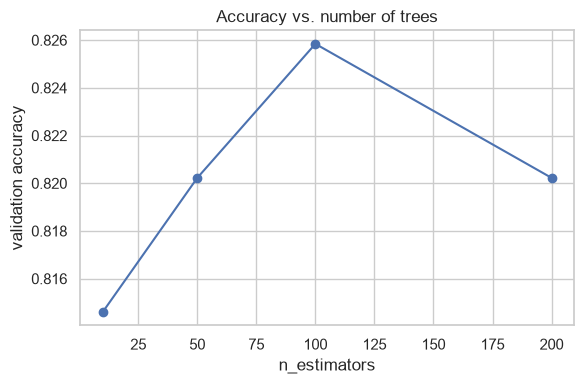

In [12]:
# Manual sweep over number of trees (fixed max_depth / min_samples_split)
n_estimators_grid = [10, 50, 100, 200]
n_estimators_results = []
for n_est in n_estimators_grid:
    forest = RandomForest(n_estimators=n_est, max_depth=8, min_samples_split=5, random_state=SEED)
    forest.fit(X_train, y_train)
    val_preds = forest.predict(X_val)
    acc = accuracy_manual(y_val, val_preds)
    n_estimators_results.append(acc)
    print(f'n_estimators={n_est:>3}  val_accuracy={acc:.4f}')

plt.figure(figsize=(6, 4))
plt.plot(n_estimators_grid, n_estimators_results, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('validation accuracy')
plt.title('Accuracy vs. number of trees')
plt.tight_layout()
plt.savefig('tuning_n_estimators.png', dpi=120)
plt.show()

max_depth=   3  val_accuracy=0.8034


max_depth=   5  val_accuracy=0.8202


max_depth=  10  val_accuracy=0.8315


max_depth=None  val_accuracy=0.8315


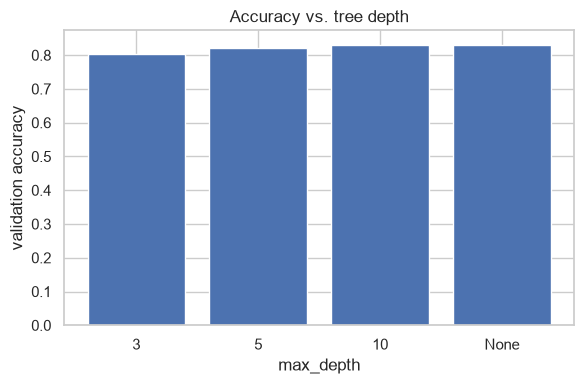

In [13]:
# Manual sweep over max_depth (fixed n_estimators / min_samples_split)
max_depth_grid = [3, 5, 10, None]
max_depth_results = []
for depth in max_depth_grid:
    forest = RandomForest(n_estimators=100, max_depth=depth, min_samples_split=5, random_state=SEED)
    forest.fit(X_train, y_train)
    val_preds = forest.predict(X_val)
    acc = accuracy_manual(y_val, val_preds)
    max_depth_results.append(acc)
    print(f'max_depth={str(depth):>4}  val_accuracy={acc:.4f}')

plt.figure(figsize=(6, 4))
plt.bar([str(d) for d in max_depth_grid], max_depth_results)
plt.xlabel('max_depth')
plt.ylabel('validation accuracy')
plt.title('Accuracy vs. tree depth')
plt.tight_layout()
plt.savefig('tuning_max_depth.png', dpi=120)
plt.show()

In [14]:
# Manual sweep over min_samples_split (fixed n_estimators / max_depth)
min_split_grid = [2, 5, 10]
min_split_results = []
for min_split in min_split_grid:
    forest = RandomForest(n_estimators=100, max_depth=10, min_samples_split=min_split, random_state=SEED)
    forest.fit(X_train, y_train)
    val_preds = forest.predict(X_val)
    acc = accuracy_manual(y_val, val_preds)
    min_split_results.append(acc)
    print(f'min_samples_split={min_split:>2}  val_accuracy={acc:.4f}')

min_samples_split= 2  val_accuracy=0.8315


min_samples_split= 5  val_accuracy=0.8315


min_samples_split=10  val_accuracy=0.8202


In [15]:
# Best config found above (edit if the sweeps above pick a different winner)
BEST_N_ESTIMATORS = n_estimators_grid[int(np.argmax(n_estimators_results))]
BEST_MAX_DEPTH = max_depth_grid[int(np.argmax(max_depth_results))]
BEST_MIN_SPLIT = min_split_grid[int(np.argmax(min_split_results))]
print('Best config:', BEST_N_ESTIMATORS, BEST_MAX_DEPTH, BEST_MIN_SPLIT)

final_forest = RandomForest(
    n_estimators=BEST_N_ESTIMATORS,
    max_depth=BEST_MAX_DEPTH,
    min_samples_split=BEST_MIN_SPLIT,
    random_state=SEED,
)
final_forest.fit(X_train, y_train)
final_preds = final_forest.predict(X_val)

acc = accuracy_manual(y_val, final_preds)
precision, recall, f1 = precision_recall_f1_manual(y_val, final_preds)
cm = confusion_matrix_manual(y_val, final_preds)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-score:  {f1:.4f}')
print('Confusion matrix (rows=actual, cols=predicted):')
print(cm)

Best config: 100 10 2


Accuracy:  0.8315
Precision: 0.8308
Recall:    0.7397
F1-score:  0.7826
Confusion matrix (rows=actual, cols=predicted):
[[94 11]
 [19 54]]


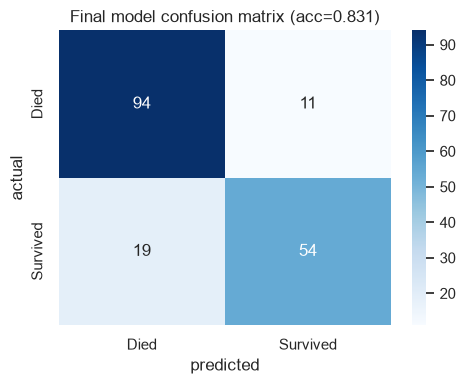

In [16]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title(f'Final model confusion matrix (acc={acc:.3f})')
plt.tight_layout()
plt.savefig('final_confusion_matrix.png', dpi=120)
plt.show()

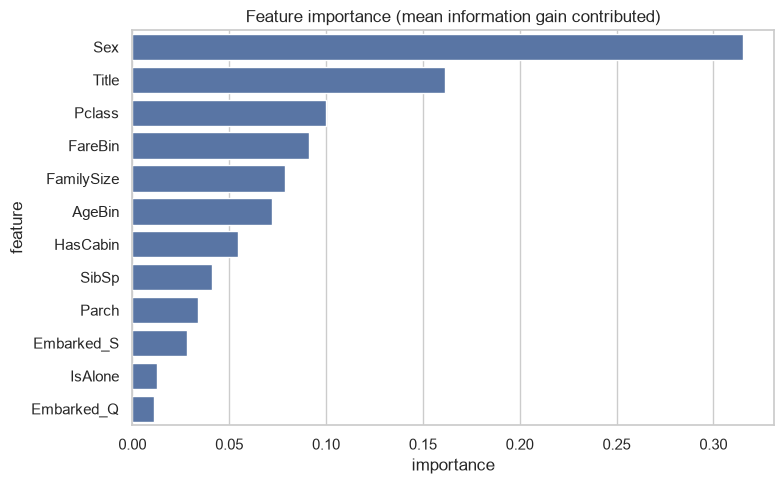

,feature,importance
1,Sex,0.315521
7,Title,0.161226
0,Pclass,0.099829
5,FareBin,0.091142
8,FamilySize,0.078577
2,AgeBin,0.072290
6,HasCabin,0.054643
3,SibSp,0.041194
4,Parch,0.033642
11,Embarked_S,0.028039


In [17]:
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': final_forest.feature_importances_,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Feature importance (mean information gain contributed)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()

importance_df

## Part 5: Analysis & insights

**Results interpretation** (best config: 100 trees, max_depth=10, min_samples_split=2):
- Final validation accuracy / precision / recall / F1: **0.8315 / 0.8308 / 0.7397 / 0.7826** (94 TN, 11 FP, 19 FN, 54 TP)
- Effect of `n_estimators`: rises from 0.8146 (10 trees) to a peak of 0.8258 at 100 trees, then flattens/slightly dips at 200. Most of the ensembling benefit is captured well before 100 trees (see `tuning_n_estimators.png`)
- Effect of `max_depth`: rises sharply from 0.8034 (depth 3) to 0.8315 at depth 10, and stays flat at unlimited depth. The bootstrap+feature-subsampling randomness in the forest is enough to prevent the overfitting a single deep tree would show (see `tuning_max_depth.png`)
- Most important features: `Sex` (0.316) by a wide margin, then `Title` (0.161), `Pclass` (0.100), `FareBin` (0.091), `FamilySize` (0.079) (see `importance_df` / `feature_importance.png`)

**Business insights**
- Which factors most influenced survival, and does that match the historical 'women and children first' account of the Titanic evacuation? Yes. `Sex` and `Title` (which largely encodes gender/marital status, e.g. Mr/Mrs/Miss/Master) together account for nearly half the total feature importance, directly matching the historical account. `Pclass` and `FareBin` being next confirms class/wealth was the second major factor, consistent with lifeboat access being easier from first-class decks.
- Any actionable takeaway if this were a real risk-scoring problem rather than a historical dataset? The model leans on a small number of dominant features (demographics + fare/class) rather than spreading importance evenly. In a live risk-scoring setting that concentration is a red flag for fairness/bias review, since two or three correlated attributes are driving most decisions.

**Model limitations**
- With `max_depth=None` and enough trees, individual trees can overfit small leaves; validation accuracy plateaued rather than dropped at the deepest setting in the `max_depth` sweep (0.8315 at both depth 10 and unlimited), so overfitting wasn't actually observed here, likely because the forest's bootstrap/feature-subsampling already regularizes it.
- No k-fold cross-validation was used, given the time constraints; a single 80/20 split's accuracy has real variance on a dataset this small (~178 validation rows), so treat the numbers above as an estimate, not a precise figure.
- The from-scratch implementation searches every candidate threshold naively (`O(features × unique values)` per split) rather than sorting once and scanning incrementally; fine at this dataset's size, but the first thing to optimize before scaling up to a much bigger dataset.